# Cricket Intelligence System
## Notebook 2 - Exploratory Data Analysis (EDA)

This notebook explores the cleaned master datasets across ODI, Test, and T20 formats.

### Steps:
1. Load cleaned master CSVs
2. Batting analysis — era trends, country dominance, top performers
3. Bowling analysis — economy evolution, top wicket takers
4. Fielding analysis — top fielders by format
5. Cross-discipline insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('darkgrid')

In [2]:
# Load cleaned master CSVs
batting = pd.read_csv('C:/cricket_intelligence/data/cleaned/batting_master.csv')
bowling = pd.read_csv('C:/cricket_intelligence/data/cleaned/bowling_master.csv')
fielding = pd.read_csv('C:/cricket_intelligence/data/cleaned/fielding_master.csv')

print(f"Batting: {batting.shape}")
print(f"Bowling: {bowling.shape}")
print(f"Fielding: {fielding.shape}")

Batting: (7507, 21)
Bowling: (7638, 23)
Fielding: (7607, 17)


In [3]:
# Quick look at batting data
print(batting.head())
print("\nColumn names:")
print(batting.columns.tolist())
print("\nData types:")
print(batting.dtypes)

             Player       Span  Mat Inns  NO   Runs     HS    Ave     BF  \
0      SR Tendulkar  1989-2012  463  452  41  18426  200.0  44.83  21367   
1     KC Sangakkara  2000-2015  404  380  41  14234  169.0  41.98  18048   
2        RT Ponting  1995-2012  375  365  39  13704  164.0  42.03  17046   
3     ST Jayasuriya  1989-2011  445  433  18  13430  189.0  32.36  14725   
4  DPMD Jayawardene  1998-2015  448  418  39  12650  144.0  33.37  16020   

      SR  ...  50   0      Country Start_Year  End_Year  Career_Length  \
0  86.23  ...  96  20        INDIA       1989      2012             24   
1  78.86  ...  93  15  Asia/ICC/SL       2000      2015             16   
2  80.39  ...  82  20      AUS/ICC       1995      2012             18   
3   91.2  ...  68  34      Asia/SL       1989      2011             23   
4  78.96  ...  77  28      Asia/SL       1998      2015             18   

   Format Discipline   4s   6s  
0     ODI    batting  NaN  NaN  
1     ODI    batting  NaN  NaN  

In [4]:
# Convert batting numeric columns
batting_numeric_cols = ['Mat', 'Inns', 'NO', 'Runs', 'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s']

for col in batting_numeric_cols:
    batting[col] = pd.to_numeric(batting[col], errors='coerce')

print("Batting dtypes after conversion:")
print(batting[batting_numeric_cols].dtypes)

Batting dtypes after conversion:
Mat       int64
Inns    float64
NO      float64
Runs    float64
Ave     float64
BF      float64
SR      float64
100     float64
50      float64
0       float64
4s      float64
6s      float64
dtype: object


In [5]:
# Convert bowling numeric columns
bowling_numeric_cols = ['Mat', 'Inns', 'Balls', 'Runs', 'Wkts', 'Ave', 'Econ', 'SR', '4', '5', 'Overs', 'Mdns']

for col in bowling_numeric_cols:
    bowling[col] = pd.to_numeric(bowling[col], errors='coerce')

print("Bowling dtypes after conversion:")
print(bowling[bowling_numeric_cols].dtypes)

Bowling dtypes after conversion:
Mat        int64
Inns     float64
Balls    float64
Runs     float64
Wkts     float64
Ave      float64
Econ     float64
SR       float64
4        float64
5        float64
Overs    float64
Mdns     float64
dtype: object


In [6]:
print(batting['Country'].unique())

['INDIA' 'Asia/ICC/SL' 'AUS/ICC' 'Asia/SL' 'Asia/PAK' 'Afr/ICC/SA'
 'Asia/INDIA' 'Asia/ICC/INDIA' 'ICC/WI' 'SL' 'Afr/SA' 'PAK' 'WI' 'AUS'
 'NZ' 'SA' 'Asia/ICC/PAK' 'ICC/NZ' 'ENG/IRE' 'BDESH' 'ZIM' 'ENG' 'ENG/ICC'
 'Afr/ZIM' 'IRE' 'Asia/BDESH' 'Afr/KENYA' 'AUS/SA' 'AFG' 'SCOT' 'KENYA'
 'CAN' 'NL' 'AUS/NZ' 'UAE' 'ENG/PNG' 'HKG' 'BMUDA' 'PNG' 'USA/WI' 'CAN/WI'
 'USA' 'ENG/SCOT' 'NAM' 'NEPAL' 'OMAN' '3' 'ICC/SA' 'HKG/NZ' 'NL/SA' 'EAf'
 'SA/USA' '1' 'ICC/INDIA' 'ICC/PAK' 'ICC/SL' 'INDIA/PAK' 'AUS/ENG' 'NZ/WI'
 'ENG/INDIA' 'ENG/SA' 'SA/ZIM' 'BDESH/ICC/World' 'SA/World' 'ICC/SL/World'
 'WI/World' 'ENG/World' 'AUS/World' 'QAT' 'MAL' 'SGP' 'VAN' 'JER'
 'AUS/ICC/NZ' 'KUW' 'Mald' 'Moz' 'CZK-R' 'Aut' 'ITA' 'GUE' 'ESP' 'GER'
 'DEN' 'NZ/World' 'Mex' 'Fin' 'AFG/ICC' 'BAH' 'ROM' 'UGA' 'MWI' 'PNM'
 'Saudi' 'THAI' 'PORT' 'GIBR' 'NGA' 'Botsw' nan 'LUX' 'Serb' 'Blz' 'Caym'
 'CRC' 'NOR' 'Arg' 'Samoa' 'MALTA' 'Peru' 'Chile' 'Belg' 'PHI' 'BHU'
 'Ghana' 'TKY' 'AFG/GER' '2' 'ICC/NEPAL' 'AUS/NL']


In [9]:
def extract_country(val):
    if pd.isna(val):
        return 'Unknown'
    parts = str(val).split('/')
    # If last part is ICC or World, take second to last
    if parts[-1] in ['ICC', 'World']:
        return parts[-2]
    return parts[-1]

# Apply to all 3 dataframes
for df in [batting, bowling, fielding]:
    df['Country'] = df['Country'].apply(extract_country)

print("Unique countries after cleaning:")
print(sorted(batting['Country'].unique()))

Unique countries after cleaning:
['1', '2', '3', 'AFG', 'AUS', 'Arg', 'Aut', 'BAH', 'BDESH', 'BHU', 'BMUDA', 'Belg', 'Blz', 'Botsw', 'CAN', 'CRC', 'CZK-R', 'Caym', 'Chile', 'DEN', 'EAf', 'ENG', 'ESP', 'Fin', 'GER', 'GIBR', 'GUE', 'Ghana', 'HKG', 'ICC', 'INDIA', 'IRE', 'ITA', 'JER', 'KENYA', 'KUW', 'LUX', 'MAL', 'MALTA', 'MWI', 'Mald', 'Mex', 'Moz', 'NAM', 'NEPAL', 'NGA', 'NL', 'NOR', 'NZ', 'OMAN', 'PAK', 'PHI', 'PNG', 'PNM', 'PORT', 'Peru', 'QAT', 'ROM', 'SA', 'SCOT', 'SGP', 'SL', 'Samoa', 'Saudi', 'Serb', 'THAI', 'TKY', 'UAE', 'UGA', 'USA', 'Unknown', 'VAN', 'WI', 'ZIM']


In [10]:
replace_map = {'1': 'Unknown', '2': 'Unknown', '3': 'Unknown', 'ICC': 'Unknown'}

for df in [batting, bowling, fielding]:
    df['Country'] = df['Country'].replace(replace_map)

In [11]:
code_to_country = {
    'INDIA': 'India', 'AUS': 'Australia', 'ENG': 'England',
    'PAK': 'Pakistan', 'SL': 'Sri Lanka', 'SA': 'South Africa',
    'WI': 'West Indies', 'NZ': 'New Zealand', 'ZIM': 'Zimbabwe',
    'BDESH': 'Bangladesh', 'AFG': 'Afghanistan', 'IRE': 'Ireland',
    'SCOT': 'Scotland', 'KENYA': 'Kenya', 'CAN': 'Canada',
    'NL': 'Netherlands', 'UAE': 'UAE', 'HKG': 'Hong Kong',
    'PNG': 'Papua New Guinea', 'USA': 'USA', 'NAM': 'Namibia',
    'NEPAL': 'Nepal', 'OMAN': 'Oman', 'BMUDA': 'Bermuda',
    'QAT': 'Qatar', 'MAL': 'Malaysia', 'SGP': 'Singapore',
    'VAN': 'Vanuatu', 'JER': 'Jersey', 'KUW': 'Kuwait',
    'Mald': 'Maldives', 'Moz': 'Mozambique', 'CZK-R': 'Czech Republic',
    'Aut': 'Austria', 'ITA': 'Italy', 'GUE': 'Guernsey',
    'ESP': 'Spain', 'GER': 'Germany', 'DEN': 'Denmark',
    'Mex': 'Mexico', 'Fin': 'Finland', 'BAH': 'Bahamas',
    'ROM': 'Romania', 'UGA': 'Uganda', 'MWI': 'Malawi',
    'PNM': 'Panama', 'Saudi': 'Saudi Arabia', 'THAI': 'Thailand',
    'PORT': 'Portugal', 'GIBR': 'Gibraltar', 'NGA': 'Nigeria',
    'Botsw': 'Botswana', 'LUX': 'Luxembourg', 'Serb': 'Serbia',
    'Blz': 'Belize', 'Caym': 'Cayman Islands', 'CRC': 'Costa Rica',
    'NOR': 'Norway', 'Arg': 'Argentina', 'Samoa': 'Samoa',
    'MALTA': 'Malta', 'Peru': 'Peru', 'Chile': 'Chile',
    'Belg': 'Belgium', 'PHI': 'Philippines', 'BHU': 'Bhutan',
    'Ghana': 'Ghana', 'TKY': 'Turkey', 'EAf': 'East Africa'
}

for df in [batting, bowling, fielding]:
    df['Country'] = df['Country'].replace(code_to_country)

print("Unique countries after full cleaning:")
print(sorted(batting['Country'].unique()))

Unique countries after full cleaning:
['Afghanistan', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Bangladesh', 'Belgium', 'Belize', 'Bermuda', 'Bhutan', 'Botswana', 'Canada', 'Cayman Islands', 'Chile', 'Costa Rica', 'Czech Republic', 'Denmark', 'East Africa', 'England', 'Finland', 'Germany', 'Ghana', 'Gibraltar', 'Guernsey', 'Hong Kong', 'India', 'Ireland', 'Italy', 'Jersey', 'Kenya', 'Kuwait', 'Luxembourg', 'Malawi', 'Malaysia', 'Maldives', 'Malta', 'Mexico', 'Mozambique', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Papua New Guinea', 'Peru', 'Philippines', 'Portugal', 'Qatar', 'Romania', 'Samoa', 'Saudi Arabia', 'Scotland', 'Serbia', 'Singapore', 'South Africa', 'Spain', 'Sri Lanka', 'Thailand', 'Turkey', 'UAE', 'USA', 'Uganda', 'Unknown', 'Vanuatu', 'West Indies', 'Zimbabwe']


In [12]:
batting.to_csv('C:/cricket_intelligence/data/cleaned/batting_master.csv', index=False)
bowling.to_csv('C:/cricket_intelligence/data/cleaned/bowling_master.csv', index=False)
fielding.to_csv('C:/cricket_intelligence/data/cleaned/fielding_master.csv', index=False)

print("Saved updated master CSVs with cleaned country column")

Saved updated master CSVs with cleaned country column


C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\1057206282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='viridis')


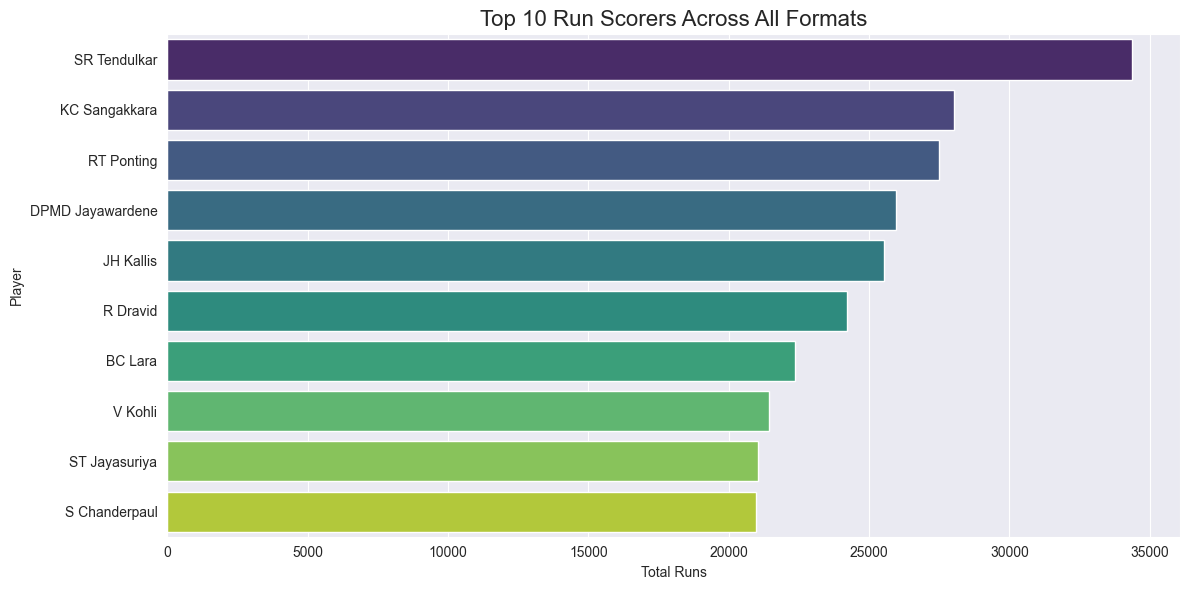

In [13]:
top_batsmen = batting.groupby('Player')['Runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='viridis')
plt.title('Top 10 Run Scorers Across All Formats', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

In [16]:
def assign_era(year):
    if year < 1970:
        return 'Pre-1970'
    elif year < 1980:
        return '1970s'
    elif year < 1990:
        return '1980s'
    elif year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    else:
        return '2010s'

In [17]:
batting['Era'] = batting['Start_Year'].apply(assign_era)
bowling['Era'] = bowling['Start_Year'].apply(assign_era)
fielding['Era'] = fielding['Start_Year'].apply(assign_era)

print(batting['Era'].value_counts())

Era
2010s       2669
2000s       1567
Pre-1970    1353
1990s        867
1980s        577
1970s        474
Name: count, dtype: int64


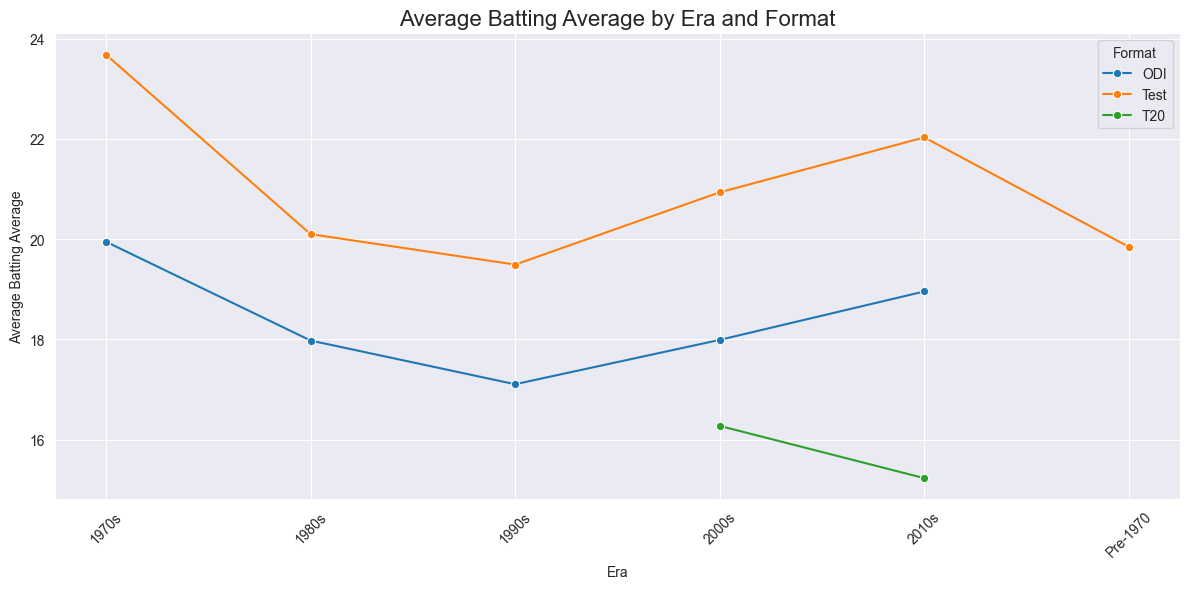

In [18]:
era_avg = batting.groupby(['Era', 'Format'])['Ave'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=era_avg, x='Era', y='Ave', hue='Format', marker='o')
plt.title('Average Batting Average by Era and Format', fontsize=16)
plt.xlabel('Era')
plt.ylabel('Average Batting Average')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\3073734550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='magma')


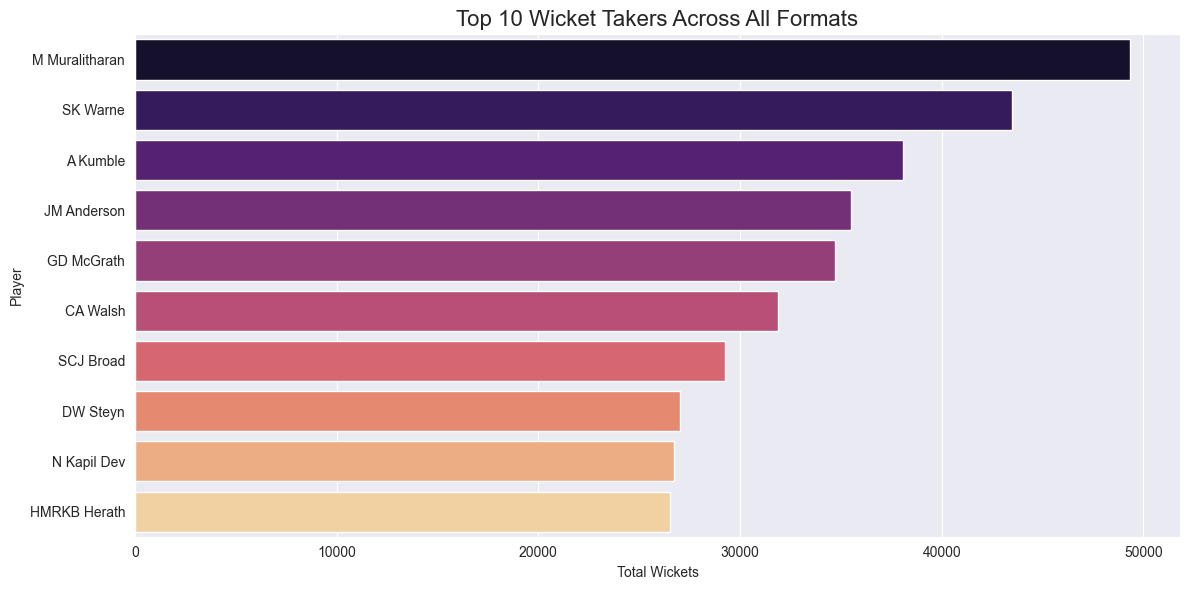

In [19]:
top_bowlers = bowling.groupby('Player')['Wkts'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='magma')
plt.title('Top 10 Wicket Takers Across All Formats', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

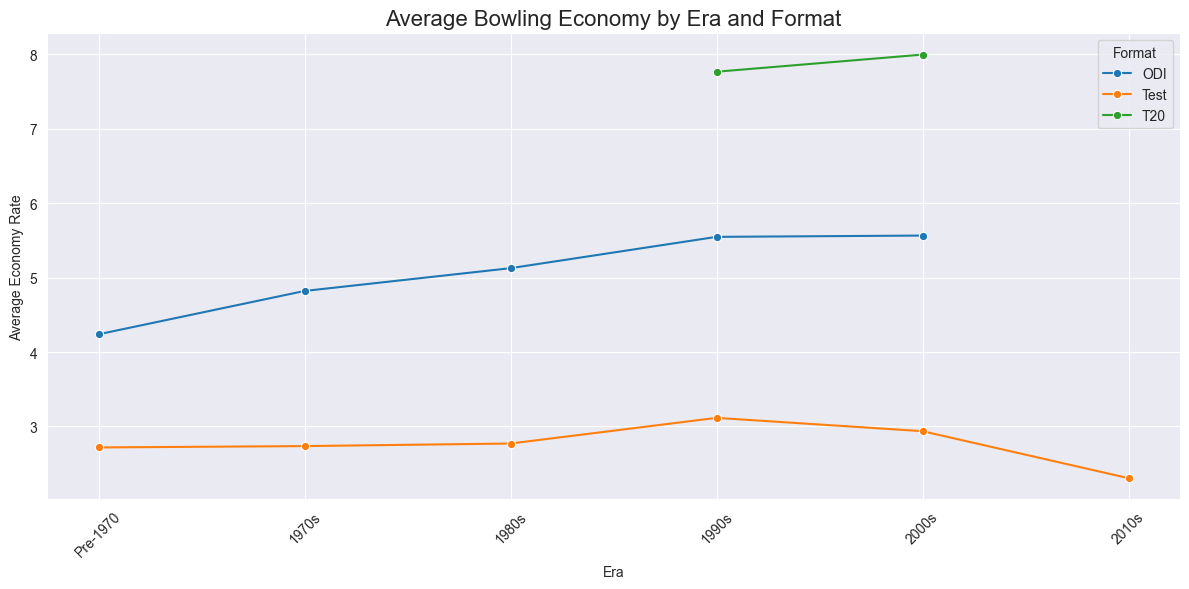

In [21]:
era_order = ['Pre-1970', '1970s', '1980s', '1990s', '2000s', '2010s']

era_econ = bowling.groupby(['Era', 'Format'])['Econ'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=era_econ, x='Era', y='Econ', hue='Format', marker='o',
             hue_order=['ODI', 'Test', 'T20'])
plt.title('Average Bowling Economy by Era and Format', fontsize=16)
plt.xlabel('Era')
plt.ylabel('Average Economy Rate')
plt.xticks(ticks=range(len(era_order)), labels=era_order, rotation=45)
plt.tight_layout()
plt.show()

C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\1485659845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')


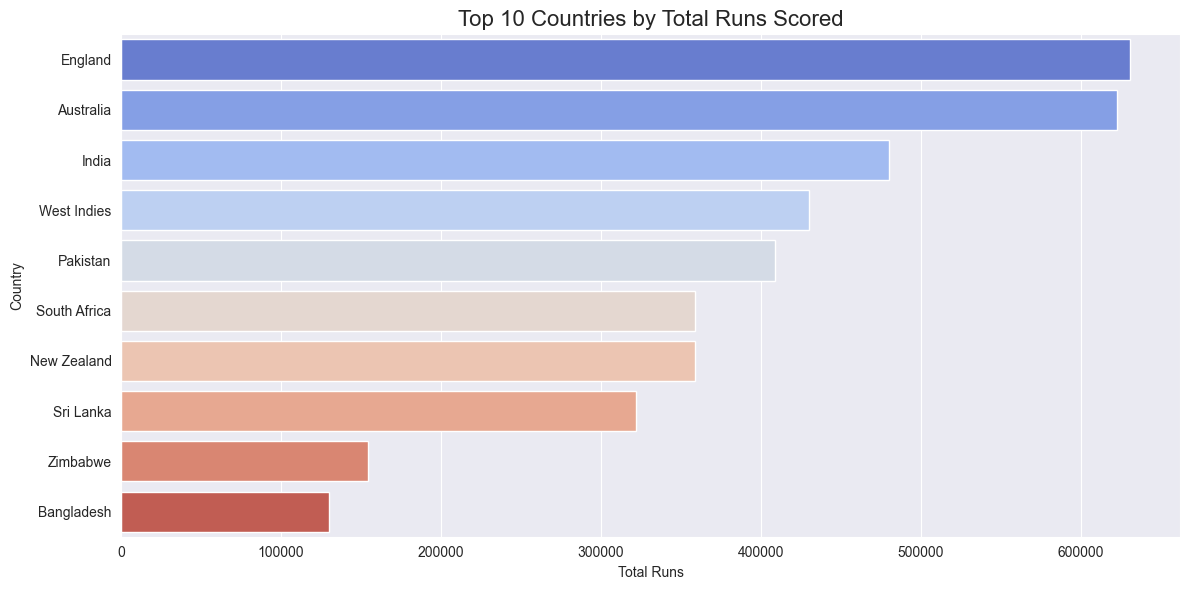

In [22]:
top_countries = batting.groupby('Country')['Runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title('Top 10 Countries by Total Runs Scored', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\2565269795.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg['Avg_Runs_Per_Player'], y=country_avg['Country'], palette='coolwarm', ax=ax)
C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\2565269795.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg['Avg_Runs_Per_Player'], y=country_avg['Country'], palette='coolwarm', ax=ax)
C:\Users\siddh\AppData\Local\Temp\ipykernel_10056\2565269795.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_avg['Avg_Runs

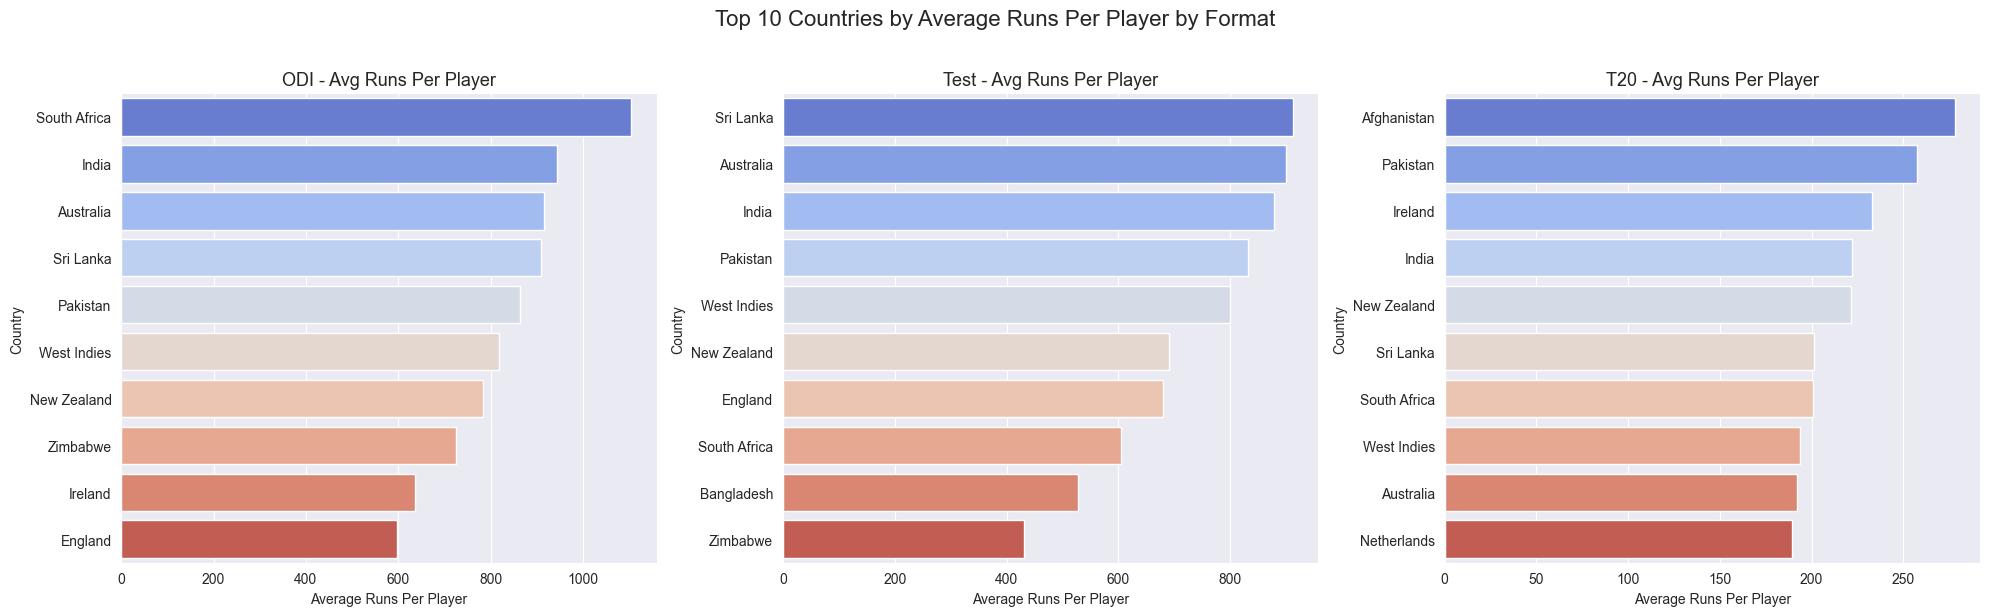

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, format_name in zip(axes, ['ODI', 'Test', 'T20']):
    format_df = batting[batting['Format'] == format_name]
    
    country_avg = format_df.groupby('Country').agg(
        Total_Runs=('Runs', 'sum'),
        Player_Count=('Player', 'count')
    ).reset_index()
    
    country_avg['Avg_Runs_Per_Player'] = country_avg['Total_Runs'] / country_avg['Player_Count']
    country_avg = country_avg[country_avg['Player_Count'] >= 20].sort_values('Avg_Runs_Per_Player', ascending=False).head(10)
    
    sns.barplot(x=country_avg['Avg_Runs_Per_Player'], y=country_avg['Country'], palette='coolwarm', ax=ax)
    ax.set_title(f'{format_name} - Avg Runs Per Player', fontsize=13)
    ax.set_xlabel('Average Runs Per Player')
    ax.set_ylabel('Country')

plt.suptitle('Top 10 Countries by Average Runs Per Player by Format', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

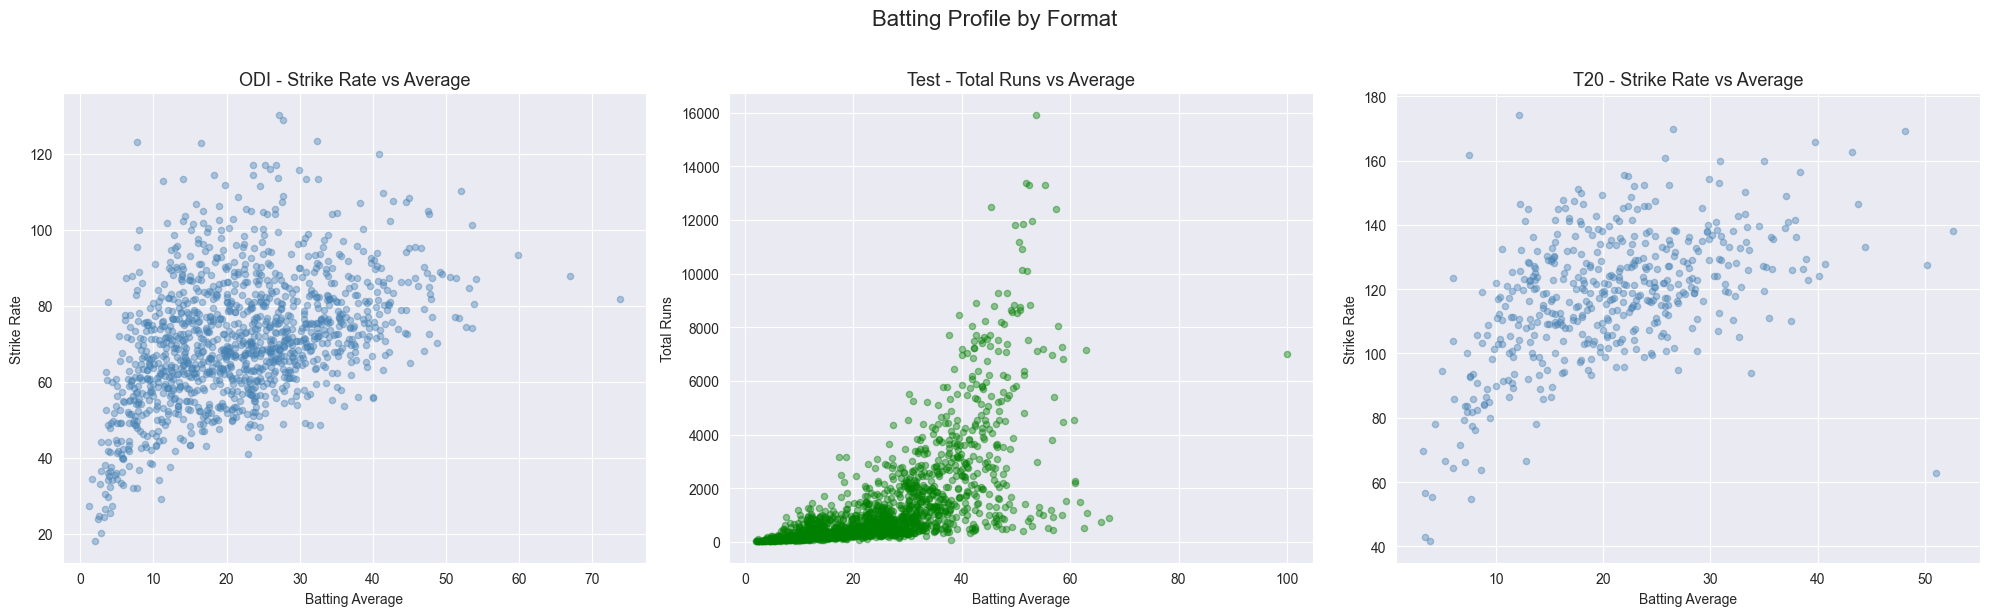

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, format_name in zip(axes, ['ODI', 'Test', 'T20']):
    format_df = batting[batting['Format'] == format_name].dropna(subset=['Ave'])
    format_df = format_df[format_df['Inns'] >= 10]
    
    if format_name == 'Test':
        format_df = format_df.dropna(subset=['Runs'])
        ax.scatter(format_df['Ave'], format_df['Runs'], alpha=0.4, s=20, color='green')
        ax.set_ylabel('Total Runs')
        ax.set_title('Test - Total Runs vs Average', fontsize=13)
    else:
        format_df = format_df.dropna(subset=['SR'])
        ax.scatter(format_df['Ave'], format_df['SR'], alpha=0.4, s=20, color='steelblue')
        ax.set_ylabel('Strike Rate')
        ax.set_title(f'{format_name} - Strike Rate vs Average', fontsize=13)
    
    ax.set_xlabel('Batting Average')

plt.suptitle('Batting Profile by Format', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
batting.to_csv('C:/cricket_intelligence/data/cleaned/batting_master.csv', index=False)
bowling.to_csv('C:/cricket_intelligence/data/cleaned/bowling_master.csv', index=False)
fielding.to_csv('C:/cricket_intelligence/data/cleaned/fielding_master.csv', index=False)

print("Saved updated master CSVs with Era column")

Saved updated master CSVs with Era column
